In [1]:
from pathlib import Path
import sys
from dataclasses import dataclass

src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from main import *
from scipy.linalg import expm
from scipy.optimize import nnls

In [2]:
# ============================================================
# Minimal helper: run bare + CD dynamics and plot comparison
# ============================================================

def run_and_plot_2LS_case(
    title,
    model,
    s_of_t,
    sdot_of_t,
    times,
    hamiltonians,
    jump_operators,
):
    # Approximate-CD evolution
    t, traj_cd, rho_cd, rho_ss, agp_data = approx_CD_trajectory(
        model=model,
        s_of_t=s_of_t,
        times=times,
        hamiltonians=hamiltonians,
        jump_operators=jump_operators,
        dim=2,
        sdot_of_t=sdot_of_t,
        lam_unitary=1e-10,
        lam_dissipative=1e-10,
        plot_residual=True,
        residual_logscale=True,
    )

    # Bare time-dependent model L(s(t))
    bare_model = LindbladModel2LS(
        lambda tt: model.H(s_of_t(tt)),
        lambda tt: model.jumps(s_of_t(tt)),
    )

    builder = LiouvillianBuilder(dim=2)

    traj_bare, rho_bare = evolve_density_matrices(
        bare_model,
        builder,
        rho_ss[0],
        t,
    )

    # Bloch vectors
    b_ss = np.array([bloch(rho) for rho in rho_ss])
    b_bare = np.array([bloch(rho) for rho in rho_bare])
    b_cd = np.array([bloch(rho) for rho in rho_cd])

    # Full density-matrix tracking errors
    error_bare = np.array([
        np.linalg.norm(rho - target, ord="fro")
        for rho, target in zip(rho_bare, rho_ss)
    ])

    error_cd = np.array([
        np.linalg.norm(rho - target, ord="fro")
        for rho, target in zip(rho_cd, rho_ss)
    ])

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig, ax = plt.subplots(
        1,
        3,
        figsize=(14, 4),
        constrained_layout=True,
    )

    # Bloch-plane trajectory
    ax[0].plot(
        b_ss[:, 0],
        b_ss[:, 2],
        "--",
        linewidth=2,
        label="instantaneous steady state",
    )
    ax[0].plot(
        b_bare[:, 0],
        b_bare[:, 2],
        label="bare",
    )
    ax[0].plot(
        b_cd[:, 0],
        b_cd[:, 2],
        label="with CD",
    )
    ax[0].scatter(
        b_ss[0, 0],
        b_ss[0, 2],
        color="black",
        s=25,
        zorder=5,
    )
    ax[0].set_xlabel(r"$\langle\sigma_x\rangle$")
    ax[0].set_ylabel(r"$\langle\sigma_z\rangle$")
    ax[0].set_title("Bloch-plane path")
    ax[0].legend(frameon=False, fontsize=8)

    # z polarisation
    ax[1].plot(
        t,
        b_ss[:, 2],
        "--",
        linewidth=2,
        label="instantaneous steady state",
    )
    ax[1].plot(t, b_bare[:, 2], label="bare")
    ax[1].plot(t, b_cd[:, 2], label="with CD")
    ax[1].set_xlabel(r"$t$")
    ax[1].set_ylabel(r"$\langle\sigma_z\rangle$")
    ax[1].set_title("Polarisation")
    ax[1].legend(frameon=False, fontsize=8)

    # Tracking error
    ax[2].plot(t, error_bare, label="bare")
    ax[2].plot(t, error_cd, label="with CD")
    ax[2].set_xlabel(r"$t$")
    ax[2].set_ylabel(
        r"$\|\rho(t)-\rho_{\rm ss}(t)\|_F$"
    )
    ax[2].set_title("Tracking error")
    ax[2].legend(frameon=False, fontsize=8)

    fig.suptitle(title)
    plt.show()

    return {
        "t": t,
        "rho_ss": rho_ss,
        "rho_bare": rho_bare,
        "rho_cd": rho_cd,
        "bloch_ss": b_ss,
        "bloch_bare": b_bare,
        "bloch_cd": b_cd,
        "error_bare": error_bare,
        "error_cd": error_cd,
        "agp_data": agp_data,
    }

## 1. Non-rotating Bloch vector
The parameter-dependent Lindbladian is

$$
\mathcal{L}_s[\rho]
=
-i\left[\frac{B_z}{2}\sigma_z,\rho\right]
+
\kappa(1+s)\mathcal{D}[\sigma_-]\rho
+
\kappa(1-s)\mathcal{D}[\sigma_+]\rho,
$$

where

$$
\mathcal{D}[L]\rho
=
L\rho L^\dagger
-\frac{1}{2}\left\{L^\dagger L,\rho\right\}.
$$

Thus the downward and upward rates are

$$
\gamma_\downarrow(s)=\kappa(1+s),
\qquad
\gamma_\uparrow(s)=\kappa(1-s).
$$

With the convention
$\sigma_z=\operatorname{diag}(1,-1)$, the instantaneous steady state is

$$
\rho_{\mathrm{ss}}(s)
=
\frac{1}{2}\left(I-s\sigma_z\right),
$$

and therefore

$$
\langle \sigma_z\rangle_{\mathrm{ss}}=-s.
$$

2


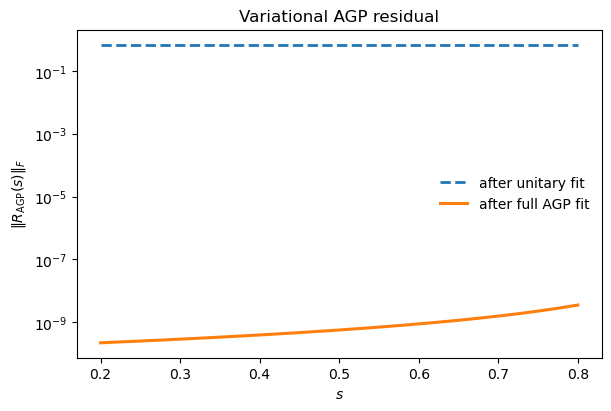

2


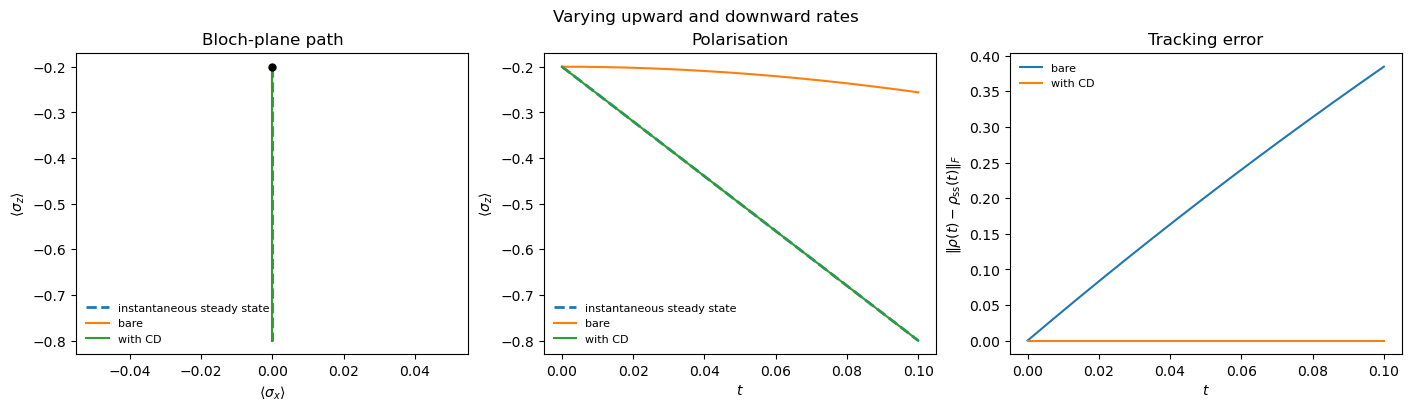

In [3]:
# ============================================================
# Case 1: varying up/down rates
# ============================================================

kappa = 1.0
Bz = 1.0

s0 = 0.2
s1 = 0.8
tau = 0.1
nsteps = 301

times = np.linspace(0.0, tau, nsteps)

# Linear ramp gives a uniform parameter grid.
s_of_t = lambda t: s0 + (s1 - s0) * t / tau
sdot_of_t = lambda t: (s1 - s0) / tau


def H_case1(s):
    return 0.5 * Bz * Pauli.sz


def jumps_case1(s):
    return [
        Jump(Pauli.sm, kappa * (1.0 + s)),
        Jump(Pauli.sp, kappa * (1.0 - s)),
    ]


model_case1 = LindbladModel2LS(
    H_case1,
    jumps_case1,
)

results_case1 = run_and_plot_2LS_case(
    title="Varying upward and downward rates",
    model=model_case1,
    s_of_t=s_of_t,
    sdot_of_t=sdot_of_t,
    times=times,
    hamiltonians=[
        Pauli.sx,
        Pauli.sy,
    ],
    jump_operators=[
        Pauli.sm,
        Pauli.sp,
    ],
)

## 2. Rotation of Bloch vector
The parameter-dependent Lindbladian is

$$
\mathcal{L}_{B_x}[\rho]
=
-i\left[
\frac{1}{2}
\left(
B_z\sigma_z+B_x\sigma_x
\right),
\rho
\right]
+
\kappa\mathcal{D}[\sigma_-]\rho,
$$

where

$$
\mathcal{D}[L]\rho
=
L\rho L^\dagger
-\frac{1}{2}\left\{L^\dagger L,\rho\right\}.
$$

Here $B_z$ and $\kappa$ are constant, while $B_x$ is the
time-dependent control parameter,

$$
B_x=B_x(t).
$$


2


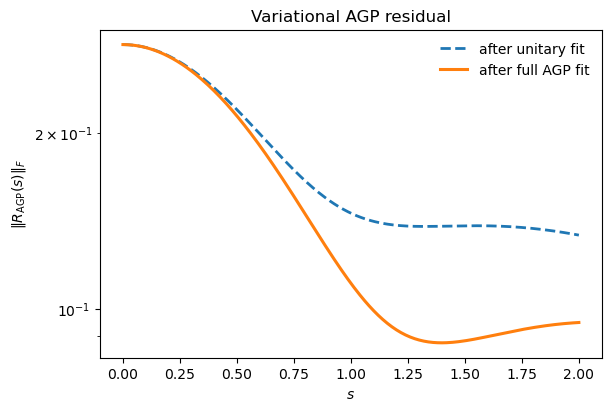

2


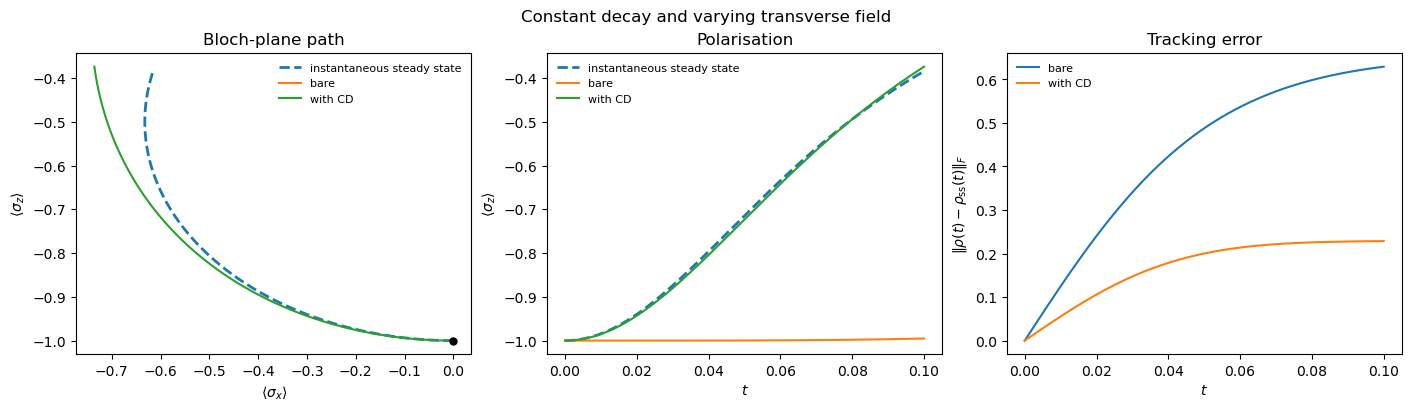

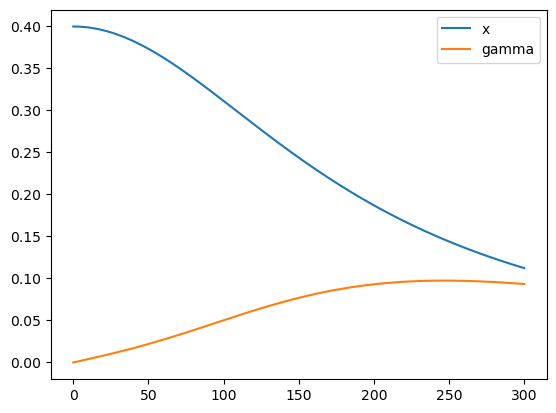

In [21]:
# ============================================================
# Case 2: constant down dissipator, varying Bx
# ============================================================

kappa = 1.0
Bz = 1.0

Bx0 = 0.0
Bx1 = 2.0
tau = 0.1
nsteps = 301

times = np.linspace(0.0, tau, nsteps)

Bx_of_t = lambda t: Bx0 + (Bx1 - Bx0) * t / tau
Bxdot_of_t = lambda t: (Bx1 - Bx0) / tau


def H_case2(Bx):
    return 0.5 * (
        Bz * Pauli.sz
        + Bx * Pauli.sx
    )


def jumps_case2(Bx):
    return [
        Jump(Pauli.sm, kappa),
    ]


model_case2 = LindbladModel2LS(
    H_case2,
    jumps_case2,
)

results_case2 = run_and_plot_2LS_case(
    title="Constant decay and varying transverse field",
    model=model_case2,
    s_of_t=Bx_of_t,
    sdot_of_t=Bxdot_of_t,
    times=times,
    hamiltonians=[
        #Pauli.sx,
        Pauli.sy,
        #Pauli.sz,
    ],
    jump_operators=[
        #Pauli.sm,
        Pauli.sp,
        #Pauli.sz,
    ]
)


plt.plot(results_case2["agp_data"]["x"], label="x")
plt.plot(results_case2["agp_data"]["gamma"], label="gamma")
plt.legend()
plt.show()